In [8]:
import os
from psd_tools import PSDImage

# Set working directory to project root (fixes relative path issues)
PROJECT_ROOT = os.path.dirname(os.path.abspath("researches.ipynb"))
os.chdir(PROJECT_ROOT)
print(f"Working directory: {os.getcwd()}")


Working directory: c:\Users\Dell\Desktop\WallBuddy-Digital-Automation-System


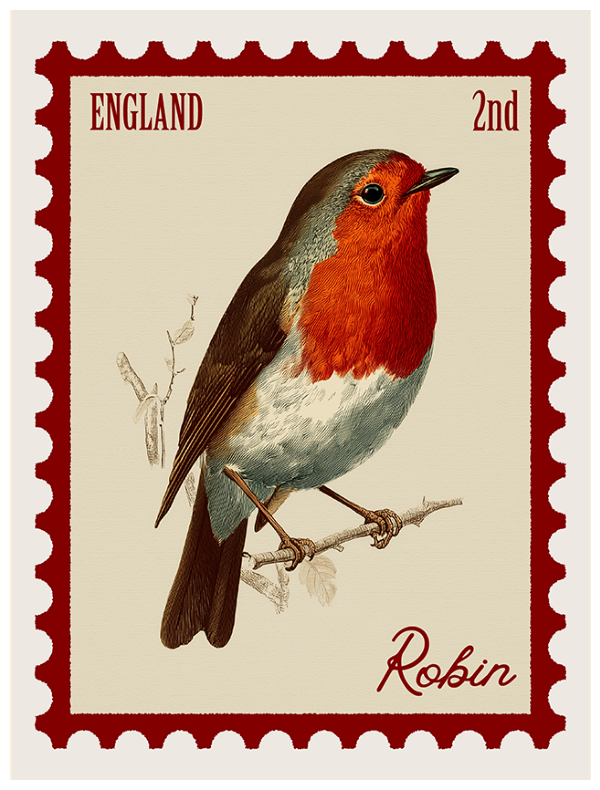

In [12]:
import matplotlib.pyplot as plt

psd = PSDImage.open('mockups/set_3/AC_SO3_3.psb') 
img = psd.composite()
plt.figure(figsize=(8, 10))
plt.imshow(img)
plt.axis('off')
plt.show()

In [5]:
from psd_tools import PSDImage

psd = PSDImage.open('mockups/set_3/1.psb')  # change to your file name

print("ALL LAYER NAMES IN THIS PSD:")
print("=" * 40)

def find_all_layers(layers, indent=0):
    for layer in layers:
        print(f"{'  ' * indent}👉 '{layer.name}'  [{layer.kind}]")
        if hasattr(layer, '__iter__'):
            find_all_layers(layer, indent + 1)

find_all_layers(psd)

ALL LAYER NAMES IN THIS PSD:
👉 'Rectangle 2'  [shape]
👉 'CAFE-03'  [smartobject]
👉 'TRIPTYCH-01'  [smartobject]


Embedded image size: (1944, 2592)
Embedded image mode: RGB


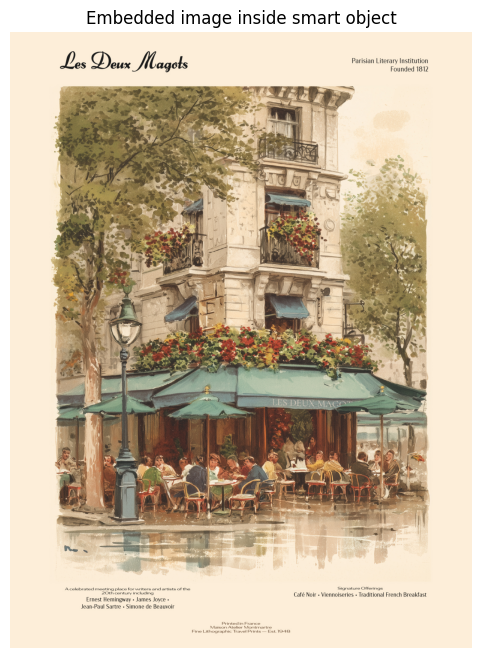

In [25]:
from psd_tools import PSDImage
from PIL import Image
import matplotlib.pyplot as plt
import io

psd = PSDImage.open('mockups/mockup1.psb')
TEST_ARTWORK = 'input/single/WB-EX-32-Edward_Robert_Hughes_Midsummer-18x24.jpg'  # change to your artwork file name

cafe_layer = list(psd)[1]

# Step 1 - Extract the embedded JPEG from inside the smart object
smart = cafe_layer.smart_object
raw_bytes = smart.data

# Step 2 - Open it as an image
embedded_img = Image.open(io.BytesIO(raw_bytes))
print(f'Embedded image size: {embedded_img.size}')
print(f'Embedded image mode: {embedded_img.mode}')

# Show it
plt.figure(figsize=(6, 8))
plt.imshow(embedded_img)
plt.title('Embedded image inside smart object')
plt.axis('off')
plt.show()

In [ ]:
import os
from psd_tools import PSDImage
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec

# ── CONFIG ────────────────────────────────────────────────────────────────
SCAN_FOLDER = "mockups/set_3"  # <-- change to any folder containing PSDs

# ── Helpers ───────────────────────────────────────────────────────────────
def layer_tree(layers, indent=0):
    lines = []
    for layer in layers:
        lines.append("  " * indent + f"[{layer.kind}] "{layer.name}"  {layer.width}x{layer.height}")
        if hasattr(layer, "__iter__"):
            lines.extend(layer_tree(layer, indent + 1))
    return lines

def preview_psd(psd_path):
    """Opens one PSD, shows composite + layer tree side by side."""
    psd = PSDImage.open(psd_path)
    composite = psd.composite()
    tree = layer_tree(psd)

    fig = plt.figure(figsize=(14, 7))
    gs  = gridspec.GridSpec(1, 2, width_ratios=[1, 1])

    ax_img = fig.add_subplot(gs[0])
    ax_img.imshow(composite)
    ax_img.axis("off")
    ax_img.set_title(os.path.basename(psd_path), fontsize=11, fontweight="bold")

    ax_txt = fig.add_subplot(gs[1])
    ax_txt.axis("off")
    ax_txt.text(
        0.02, 0.98,
        f"Canvas: {psd.width} x {psd.height}

" + "
".join(tree),
        transform=ax_txt.transAxes,
        va="top", ha="left",
        fontsize=9, family="monospace",
    )

    plt.tight_layout()
    plt.show()
    print("-" * 60)

# ── Scan folder ───────────────────────────────────────────────────────────
psd_files = sorted(
    f.path for f in os.scandir(SCAN_FOLDER)
    if f.is_file() and f.name.lower().endswith((".psd", ".psb"))
)

if not psd_files:
    print(f"No PSD/PSB files found in: {SCAN_FOLDER}")
else:
    print(f"Found {len(psd_files)} file(s) in {SCAN_FOLDER}:")
    for p in psd_files:
        print(f"  {os.path.basename(p)}")
    print()
    for psd_path in psd_files:
        preview_psd(psd_path)
